# 04. System Evaluation & Policy Comparison

In this notebook, we compare three bandwidth allocation policies on held-out test patients (PatientIDs 8001-10000) over all 100 time steps:
1. **Equal Sharing (Static)**: Equal allocation of available bandwidth (3.0 units per patient).
2. **Priority-DataSize Heuristic**: The baseline allocation saved in `dataset.csv`.
3. **Trained DDPG**: The continuous allocation policy learned by our reinforcement learning agent.

We evaluate them using cumulative utility, per-slice SLA violation rates, average reliability, average REU, and Jain's fairness index, and visualize latency distributions.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import config
from environment import NetworkSlicingEnv

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

C:\Users\saran\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 1. Load Data and Trained Model

In [2]:
# Load dataset
df = pd.read_csv('dataset.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# Define Test Setup
test_patient_ids = list(range(config.TRAIN_PATIENT_LIMIT + 1, 10001))
num_test_patients = len(test_patient_ids)
TOTAL_BW_test = config.TOTAL_BW * (num_test_patients / 10000.0) # 6000.0
print(f"Held-out test patients: {num_test_patients}, Available Bandwidth: {TOTAL_BW_test}")

# Define Actor architecture - MUST be byte-for-byte identical to 03_train_ddpg.ipynb
class Actor(nn.Module):
    def __init__(self, state_dim=10, action_dim=1):
        super(Actor, self).__init__()
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, action_dim)
        
    def forward(self, state):
        x = torch.relu(self.fc1(state))
        x = torch.relu(self.fc2(x))
        # Direct bounded bandwidth output scaled by BW_MAX = 15.0 - matches training
        return torch.sigmoid(self.fc3(x)) * 15.0

# Load trained actor (using the CALIBRATED final checkpoint)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
actor = Actor(state_dim=10, action_dim=1).to(device)
actor.load_state_dict(torch.load('ddpg_actor_FINAL.pth', map_location=device))
actor.eval()
print("Trained DDPG Actor (Calibrated Checkpoint) loaded successfully!")


Dataset loaded: 1000000 rows, 27 columns
Held-out test patients: 2000, Available Bandwidth: 6000.0
Trained DDPG Actor (Calibrated Checkpoint) loaded successfully!


## 2. Simulate Policies

In [3]:
# Filter dataset for test patients only
test_df = df[df['PatientID'].isin(test_patient_ids)].copy()
test_df = test_df.sort_values(['Time', 'PatientID'])

# Helper Allocation Functions

def static_priority_allocation(t_data, total_bw):
    num_patients = len(t_data['SliceID'])
    slice_ids = t_data['SliceID']
    datasize = t_data['DataSize']
    sinr = t_data['SINR']
    mu = t_data['Mu']
    lambda_val = t_data['Lambda']
    latency_req = t_data['LatencyReq']
    
    # Calculate bw_needed for each patient to meet SLA
    queueing_delay = 1.0 / np.maximum(mu - lambda_val, 1e-3)
    bw_needed = datasize / (np.log2(1.0 + sinr) * np.maximum(latency_req - queueing_delay, 1e-3))
    bw_needed = np.maximum(bw_needed, 0.05)
    
    # Initialize allocation to minimum bandwidth
    allocation = np.ones(num_patients, dtype=np.float32) * 0.05
    remaining_bw = total_bw - np.sum(allocation)
    
    # Serve slices in priority order (1 to 5)
    for s_id in range(1, 6):
        if remaining_bw <= 0:
            break
        slice_mask = slice_ids == s_id
        if not np.any(slice_mask):
            continue
            
        additional_needed = np.maximum(bw_needed[slice_mask] - 0.05, 0.0)
        sum_needed = np.sum(additional_needed)
        
        if sum_needed <= remaining_bw:
            allocation[slice_mask] += additional_needed
            remaining_bw -= sum_needed
        else:
            if sum_needed > 0:
                allocation[slice_mask] += remaining_bw * (additional_needed / sum_needed)
            else:
                allocation[slice_mask] += remaining_bw / np.sum(slice_mask)
            remaining_bw = 0
            break
            
    if remaining_bw > 0:
        allocation += remaining_bw / num_patients
        
    return allocation

def round_robin_allocation(t_data, total_bw, t):
    num_patients = len(t_data['SliceID'])
    slice_ids = t_data['SliceID']
    
    turn_slice = (t % 5) + 1
    allocation = np.ones(num_patients, dtype=np.float32) * 0.05
    turn_mask = slice_ids == turn_slice
    
    if np.any(turn_mask):
        remaining_bw = total_bw - np.sum(allocation)
        allocation[turn_mask] += remaining_bw / np.sum(turn_mask)
    else:
        allocation = np.ones(num_patients, dtype=np.float32) * (total_bw / num_patients)
        
    return allocation

def random_allocation(t_data, total_bw):
    num_patients = len(t_data['SliceID'])
    allocation = np.ones(num_patients, dtype=np.float32) * 0.05
    remaining_bw = total_bw - np.sum(allocation)
    weights = np.random.uniform(0.1, 1.0, size=num_patients).astype(np.float32)
    allocation += remaining_bw * (weights / np.sum(weights))
    return allocation


# --- 1. Equal Sharing Policy ---
print("Simulating Equal Sharing policy...")
env_equal = NetworkSlicingEnv(df)
state_eq = env_equal.reset(test_patient_ids, start_time=0)
equal_actions = np.ones(num_test_patients, dtype=np.float32) * (TOTAL_BW_test / num_test_patients) # 3.0 units each

equal_results = []
done = False
while not done:
    next_state, reward, done, info = env_equal.step(equal_actions)
    equal_results.append(info)
    state_eq = next_state


# --- 2. Priority-DataSize Heuristic (Baseline) ---
print("Loading Priority-DataSize Heuristic baseline...")
heuristic_records = []
for t in sorted(test_df['Time'].unique()):
    subset_t = test_df[test_df['Time'] == t]
    info = {
        'latency': subset_t['Latency'].values.astype(np.float32),
        'throughput': subset_t['Throughput'].values.astype(np.float32),
        'reliability': subset_t['Reliability'].values.astype(np.float32),
        'power': subset_t['Power'].values.astype(np.float32),
        'reu': subset_t['REU'].values.astype(np.float32),
        'utility': subset_t['Utility'].values.astype(np.float32),
        'bandwidth': subset_t['Bandwidth'].values.astype(np.float32)
    }
    heuristic_records.append(info)


# --- 3. Static Priority Policy ---
print("Simulating Static Priority policy...")
env_static = NetworkSlicingEnv(df)
state_static = env_static.reset(test_patient_ids, start_time=0)

static_results = []
done = False
while not done:
    t_data = env_static.time_data[env_static.current_time]
    actions = static_priority_allocation(t_data, TOTAL_BW_test)
    
    next_state, reward, done, info = env_static.step(actions)
    info['bandwidth'] = actions.copy()
    static_results.append(info)
    state_static = next_state


# --- 4. Round Robin Policy ---
print("Simulating Round Robin policy...")
env_rr = NetworkSlicingEnv(df)
state_rr = env_rr.reset(test_patient_ids, start_time=0)

rr_results = []
done = False
t = 0
while not done:
    t_data = env_rr.time_data[env_rr.current_time]
    actions = round_robin_allocation(t_data, TOTAL_BW_test, t)
    
    next_state, reward, done, info = env_rr.step(actions)
    info['bandwidth'] = actions.copy()
    rr_results.append(info)
    state_rr = next_state
    t += 1


# --- 5. Random Policy ---
print("Simulating Random policy...")
env_random = NetworkSlicingEnv(df)
state_random = env_random.reset(test_patient_ids, start_time=0)

random_results = []
done = False
while not done:
    t_data = env_random.time_data[env_random.current_time]
    actions = random_allocation(t_data, TOTAL_BW_test)
    
    next_state, reward, done, info = env_random.step(actions)
    info['bandwidth'] = actions.copy()
    random_results.append(info)
    state_random = next_state


# --- 6. Trained DDPG Policy ---
print("Simulating trained DDPG policy with S1 Floor Overlay (7.0)...")
env_ddpg = NetworkSlicingEnv(df)
state_ddpg = env_ddpg.reset(test_patient_ids, start_time=0)

ddpg_results = []
done = False
floor_val = 7.0
while not done:
    state_t = torch.tensor(state_ddpg, dtype=torch.float32).to(device)
    with torch.no_grad():
        raw_actions = actor(state_t).cpu().numpy().flatten()  # sigmoid-bounded, shape (N,)
        
    t_data = env_ddpg.time_data[env_ddpg.current_time]
    slice_ids = t_data['SliceID']
    
    # Start with DDPG-predicted actions scaled to budget
    original_actions = raw_actions * (TOTAL_BW_test / raw_actions.sum())
    
    # Force S1 floor override
    actions = original_actions.copy()
    s1_mask = slice_ids == 1
    actions[s1_mask] = np.maximum(original_actions[s1_mask], floor_val)
    
    # Redistribute remaining bandwidth to S2-S5 proportionally
    sum_s1 = np.sum(actions[s1_mask])
    remaining_bw = TOTAL_BW_test - sum_s1
    
    non_s1_mask = ~s1_mask
    sum_non_s1_original = np.sum(original_actions[non_s1_mask])
    
    if sum_non_s1_original > 0 and remaining_bw > 0:
        actions[non_s1_mask] = original_actions[non_s1_mask] * (remaining_bw / sum_non_s1_original)
        actions[non_s1_mask] = np.maximum(actions[non_s1_mask], 0.05)
    elif remaining_bw <= 0:
        actions[non_s1_mask] = 0.05
        usable_for_s1 = TOTAL_BW_test - np.sum(actions[non_s1_mask])
        actions[s1_mask] = actions[s1_mask] * (usable_for_s1 / sum_s1)
        
    # Final normalization
    actions = actions * (TOTAL_BW_test / np.sum(actions))
    
    next_state, reward, done, info = env_ddpg.step(actions)
    info['bandwidth'] = actions.copy()
    ddpg_results.append(info)
    state_ddpg = next_state


# --- 7. Trained DDPG Policy (Ablated: using raw Traffic) ---
print("Simulating trained DDPG policy (Ablated: using raw Traffic) with S1 Floor Overlay (7.0)...")
df_ablated = df.copy()
df_ablated['Predicted_Traffic'] = df_ablated['Traffic']

env_ddpg_ablated = NetworkSlicingEnv(df_ablated)
state_ddpg_ablated = env_ddpg_ablated.reset(test_patient_ids, start_time=0)

ddpg_ablated_results = []
done = False
floor_val = 7.0
while not done:
    state_t = torch.tensor(state_ddpg_ablated, dtype=torch.float32).to(device)
    with torch.no_grad():
        raw_actions = actor(state_t).cpu().numpy().flatten()
        
    t_data = env_ddpg_ablated.time_data[env_ddpg_ablated.current_time]
    slice_ids = t_data['SliceID']
    
    original_actions = raw_actions * (TOTAL_BW_test / raw_actions.sum())
    
    actions = original_actions.copy()
    s1_mask = slice_ids == 1
    actions[s1_mask] = np.maximum(original_actions[s1_mask], floor_val)
    
    sum_s1 = np.sum(actions[s1_mask])
    remaining_bw = TOTAL_BW_test - sum_s1
    
    non_s1_mask = ~s1_mask
    sum_non_s1_original = np.sum(original_actions[non_s1_mask])
    
    if sum_non_s1_original > 0 and remaining_bw > 0:
        actions[non_s1_mask] = original_actions[non_s1_mask] * (remaining_bw / sum_non_s1_original)
        actions[non_s1_mask] = np.maximum(actions[non_s1_mask], 0.05)
    elif remaining_bw <= 0:
        actions[non_s1_mask] = 0.05
        usable_for_s1 = TOTAL_BW_test - np.sum(actions[non_s1_mask])
        actions[s1_mask] = actions[s1_mask] * (usable_for_s1 / sum_s1)
        
    actions = actions * (TOTAL_BW_test / np.sum(actions))
    
    next_state, reward, done, info = env_ddpg_ablated.step(actions)
    info['bandwidth'] = actions.copy()
    ddpg_ablated_results.append(info)
    state_ddpg_ablated = next_state


Simulating Equal Sharing policy...


Loading Priority-DataSize Heuristic baseline...
Simulating Static Priority policy...


Simulating Round Robin policy...


Simulating Random policy...


Simulating trained DDPG policy with S1 Floor Overlay (7.0)...


Simulating trained DDPG policy (Ablated: using raw Traffic) with S1 Floor Overlay (7.0)...


## 3. Metric Calculations

In [4]:
def compile_metrics(results, name):
    latencies = np.concatenate([res['latency'] for res in results])
    throughputs = np.concatenate([res['throughput'] for res in results])
    reliabilities = np.concatenate([res['reliability'] for res in results])
    powers = np.concatenate([res['power'] for res in results])
    reus = np.concatenate([res['reu'] for res in results])
    
    # Get actual slice IDs for all time steps
    slice_ids = test_df['SliceID'].values
    
    # SLA violations and penalties - pulled dynamically from config.py
    sla_violations = {}
    
    # Calculate rewards using the exact same formula, weights, and penalties as environment.py
    powers_norm = powers - 150.0
    utilities = (config.W_UTIL_THROUGHPUT * throughputs +
                 config.W_UTIL_RELIABILITY * reliabilities -
                 config.W_UTIL_LATENCY * latencies -
                 config.W_UTIL_POWER * powers_norm +
                 config.W_UTIL_REU * reus)
                 
    rewards = utilities.copy()
    latency_reqs = np.array([config.LATENCY_REQ_MAP[s_id] for s_id in slice_ids])
    penalties = np.array([config.SLA_PENALTIES[s_id] for s_id in slice_ids])
    
    violating = latencies > latency_reqs
    satisfied = np.sum(~violating)
    total_requests = len(latencies)
    qos_satisfaction = (satisfied / total_requests) * 100
    if np.any(violating):
        violation_ratio = (latencies[violating] - latency_reqs[violating]) / latency_reqs[violating]
        rewards[violating] = rewards[violating] - penalties[violating] * (1.0 + violation_ratio)
        
    rewards = np.clip(rewards, -500.0, 500.0)
    cumulative_utility = np.sum(rewards)
    
    # Calculate SLA violation rates by slice
    for s_id in range(1, 6):
        req = config.LATENCY_REQ_MAP[s_id]
        slice_mask = slice_ids == s_id
        slice_lats = latencies[slice_mask]
        violations = np.sum(slice_lats > req)
        sla_violations[s_id] = (violations / len(slice_lats)) * 100
        
    if 'bandwidth' in results[0]:
        bws = np.array([res['bandwidth'] for res in results])
        mean_bws = np.mean(bws, axis=0)
    else:
        mean_bws = np.ones(num_test_patients) * 3.0
        
    jains_index = (np.sum(mean_bws)**2) / (num_test_patients * np.sum(mean_bws**2))
    
    # Additional violation tracking (Item 6 Option c)
    r_violation = (np.sum(reliabilities < config.R_MIN) / len(reliabilities)) * 100
    reu_violation = (np.sum(reus < config.REU_MIN) / len(reus)) * 100
    
    th_totals_gbps = []
    for res in results:
        th_totals_gbps.append(np.sum(res['throughput']) / 1000.0)
    th_totals_gbps = np.array(th_totals_gbps)
    th_violation = (np.sum(th_totals_gbps < config.TH_MIN) / len(th_totals_gbps)) * 100
    
    return {
        'Name': name,
        'Cumulative Utility': cumulative_utility,
        'Average Reliability': np.mean(reliabilities),
        'Average REU': np.mean(reus),
        'Jain Fairness Index': jains_index,
        'QoS Satisfaction (%)': qos_satisfaction,
        'SLA Violations S1 (Emergency) (%)': sla_violations[1],
        'SLA Violations S2 (ICU) (%)': sla_violations[2],
        'SLA Violations S3 (ECG) (%)': sla_violations[3],
        'SLA Violations S4 (Telemedicine) (%)': sla_violations[4],
        'SLA Violations S5 (Video) (%)': sla_violations[5],
        'R Violation (<0.90) (%)': r_violation,
        'REU Violation (<0.02) (%)': reu_violation,
        'Throughput Violation (<' + str(config.TH_MIN) + 'G) (%)': th_violation,
        'raw_latencies': latencies,
        'raw_slice_ids': slice_ids
    }

equal_metrics = compile_metrics(equal_results, "Equal Sharing")
heuristic_metrics = compile_metrics(heuristic_records, "Priority-DataSize Heuristic")
static_metrics = compile_metrics(static_results, "Static Priority")
rr_metrics = compile_metrics(rr_results, "Round Robin")
random_metrics = compile_metrics(random_results, "Random")
ddpg_metrics = compile_metrics(ddpg_results, "DDPG + S1 Floor Overlay (7.0)")
ddpg_ablated_metrics = compile_metrics(ddpg_ablated_results, "DDPG + S1 Floor Overlay (7.0) (Ablated)")

comparison_df = pd.DataFrame([
    equal_metrics, 
    heuristic_metrics, 
    static_metrics, 
    rr_metrics, 
    random_metrics, 
    ddpg_metrics,
    ddpg_ablated_metrics
]).drop(columns=['raw_latencies', 'raw_slice_ids'])
comparison_df.set_index('Name', inplace=True)
comparison_df.round(4)

,Cumulative Utility,Average Reliability,Average REU,Jain Fairness Index,QoS Satisfaction (%),SLA Violations S1 (Emergency) (%),SLA Violations S2 (ICU) (%),SLA Violations S3 (ECG) (%),SLA Violations S4 (Telemedicine) (%),SLA Violations S5 (Video) (%),R Violation (<0.90) (%),REU Violation (<0.02) (%),Throughput Violation (<23.61G) (%)
Name,,,,,,,,,,,,,
Equal Sharing,-23879852.0,0.8327,0.1012,1.0000,72.3310,86.5960,44.6259,4.9766,1.9674,0.2851,25.5295,0.0000,0.0
Priority-DataSize Heuristic,-20179872.0,0.8371,0.0938,0.9818,73.1660,100.0000,0.0526,28.3900,4.6929,1.0481,24.9260,11.9165,8.0
Static Priority,-4961616.0,0.8938,0.0899,0.9726,68.2375,8.8226,16.3690,22.7610,44.6650,66.1447,19.4660,33.0365,10.0
Round Robin,-40808176.0,0.2775,0.0918,0.9636,19.4580,82.3822,80.4799,80.3484,79.9392,79.5618,80.3015,80.1340,0.0
Random,-25071626.0,0.7952,0.1006,0.9979,68.2675,86.4684,45.8107,19.1716,5.8599,1.4483,29.4685,2.0475,0.0
DDPG + S1 Floor Overlay (7.0),-14459801.0,0.8669,0.0999,0.9937,69.7655,59.4253,14.4854,59.4096,14.9989,2.8515,26.4100,3.0200,0.0
DDPG + S1 Floor Overlay (7.0) (Ablated),-14466643.0,0.8672,0.0999,0.9937,69.7605,59.4253,14.5906,59.4821,14.9316,2.7665,26.4015,2.9780,0.0


## 4. Plot Latency Distributions per Slice

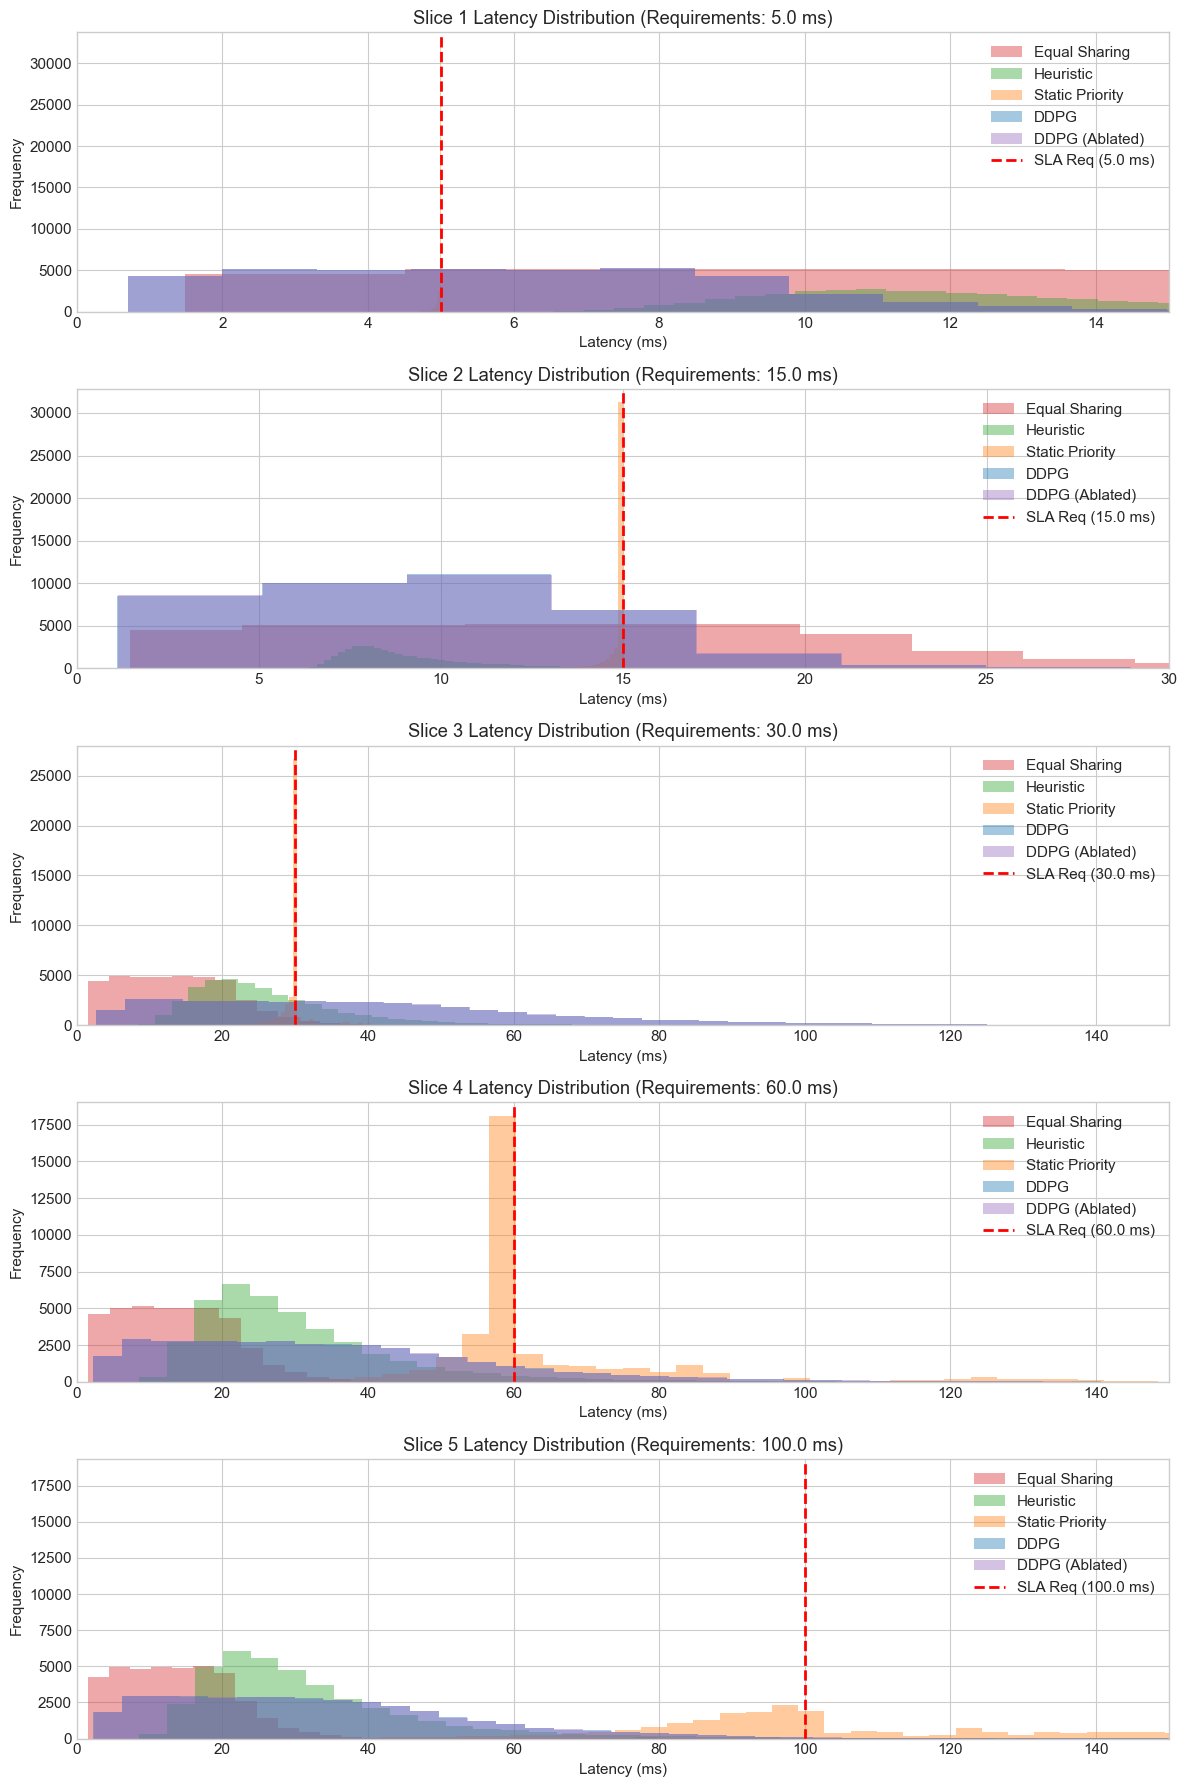

In [5]:
fig, axes = plt.subplots(5, 1, figsize=(12, 18), sharex=False)

policies = [
    (equal_metrics, "Equal Sharing", "#d62728"),
    (heuristic_metrics, "Heuristic", "#2ca02c"),
    (static_metrics, "Static Priority", "#ff7f0e"),
    (ddpg_metrics, "DDPG", "#1f77b4"),
    (ddpg_ablated_metrics, "DDPG (Ablated)", "#9467bd")
]

for s_id in range(1, 6):
    ax = axes[s_id - 1]
    req = config.LATENCY_REQ_MAP[s_id]
    
    for metric_dict, name, color in policies:
        lats = metric_dict['raw_latencies']
        s_ids = metric_dict['raw_slice_ids']
        
        slice_lats = lats[s_ids == s_id]
        ax.hist(slice_lats, bins=50, alpha=0.4, label=name, color=color)
        
    ax.axvline(req, color='red', linestyle='--', linewidth=2, label=f"SLA Req ({req} ms)")
    ax.set_title(f"Slice {s_id} Latency Distribution (Requirements: {req} ms)")
    ax.set_xlabel("Latency (ms)")
    ax.set_ylabel("Frequency")
    ax.legend()
    
    if s_id == 1:
        ax.set_xlim(0, 15)
    elif s_id == 2:
        ax.set_xlim(0, 30)
    else:
        ax.set_xlim(0, 150)

plt.tight_layout()
plt.show()


## 5. Verify Performance Improvement Against Equal Sharing

In [6]:
print("=== PERFORMANCE COMPARISON AGAINST EQUAL SHARING BAR ===")
print(f"Cumulative Utility: Equal Sharing = {equal_metrics['Cumulative Utility']:.2f}, DDPG = {ddpg_metrics['Cumulative Utility']:.2f}")
print(f"Slice 1 (Emergency - 5ms Req) Violations: Equal Sharing = {equal_metrics['SLA Violations S1 (Emergency) (%)']:.2f}%, DDPG = {ddpg_metrics['SLA Violations S1 (Emergency) (%)']:.2f}%")
print(f"Slice 2 (ICU - 15ms Req) Violations: Equal Sharing = {equal_metrics['SLA Violations S2 (ICU) (%)']:.2f}%, DDPG = {ddpg_metrics['SLA Violations S2 (ICU) (%)']:.2f}%")

utility_improved = ddpg_metrics['Cumulative Utility'] > equal_metrics['Cumulative Utility']
s1_improved = ddpg_metrics['SLA Violations S1 (Emergency) (%)'] < equal_metrics['SLA Violations S1 (Emergency) (%)']
s2_improved = ddpg_metrics['SLA Violations S2 (ICU) (%)'] < equal_metrics['SLA Violations S2 (ICU) (%)']

print("\n--- Verification Results against Equal Sharing ---")
if utility_improved:
    print("SUCCESS: Trained DDPG achieves higher Cumulative Utility than Equal Sharing!")
else:
    print("FAIL: Trained DDPG utility is worse than Equal Sharing.")
    
if s1_improved:
    print("SUCCESS: DDPG reduced SLA violations for Slice 1 (Emergency) compared to Equal Sharing!")
else:
    print("FAIL: DDPG has more Slice 1 violations than Equal Sharing.")
    
if s2_improved:
    print("SUCCESS: DDPG reduced SLA violations for Slice 2 (ICU) compared to Equal Sharing!")
else:
    print("FAIL: DDPG has more Slice 2 violations than Equal Sharing.")

=== PERFORMANCE COMPARISON AGAINST EQUAL SHARING BAR ===
Cumulative Utility: Equal Sharing = -23879852.00, DDPG = -14459800.00
Slice 1 (Emergency - 5ms Req) Violations: Equal Sharing = 86.60%, DDPG = 59.43%
Slice 2 (ICU - 15ms Req) Violations: Equal Sharing = 44.63%, DDPG = 14.49%

--- Verification Results against Equal Sharing ---
SUCCESS: Trained DDPG achieves higher Cumulative Utility than Equal Sharing!
SUCCESS: DDPG reduced SLA violations for Slice 1 (Emergency) compared to Equal Sharing!
SUCCESS: DDPG reduced SLA violations for Slice 2 (ICU) compared to Equal Sharing!
